In [60]:
import math
import numpy as np
import matplotlib.pyplot as plt

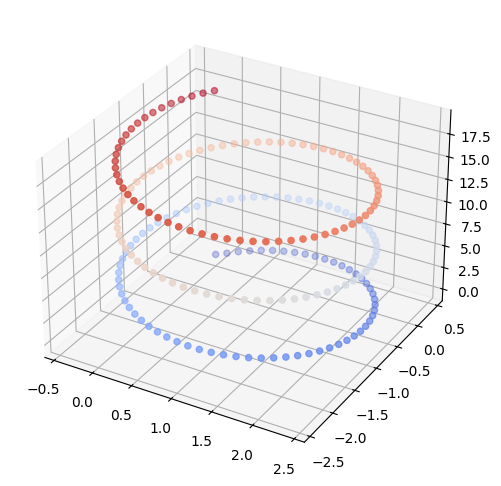

In [61]:
q = 1
B = 1
E = 0
m = 1

N=200
nt = 100

def g(state,t):
    x, vx, y, vy = state[0], state[1], state[2], state[3]

    v = np.zeros(4)
    v[0] = vx
    v[1] = q/m*(B*vy + E)
    v[2] = vy
    v[3] = q/m*(-B*vx)
    return v

def rungeKutta(y, t, dt):
    C1 = g(y, t)
    C2 = g(y + dt*C1/2, t + dt/2)
    C3 = g(y + dt*C2/2, t + dt/2)
    C4 = g(y + dt*C3,   t + dt)
    return y + dt*(C1 + 2*C2 + 2*C3 + C4)/6

DT = 3*math.pi/nt
V0Z = 1
Z0 = 0

X1 = np.zeros(N+1)
Y1 = np.zeros(N+1)
Z1 = np.zeros(N+1)
   

Y = np.array([0,1,0,1])
for i in range(N):
    t = DT*i
    Y = rungeKutta(Y, t, DT)
    X1[i+1] = Y[0]               
    Y1[i+1] = Y[2]    
    Z1[i+1] = V0Z*t + Z0           

fig = plt.figure(figsize=(8,6))  
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1, Y1, Z1, c=np.arange(N+1), cmap='coolwarm', marker='o')
plt.show()

Invariante adiabatico del ciclotrone.

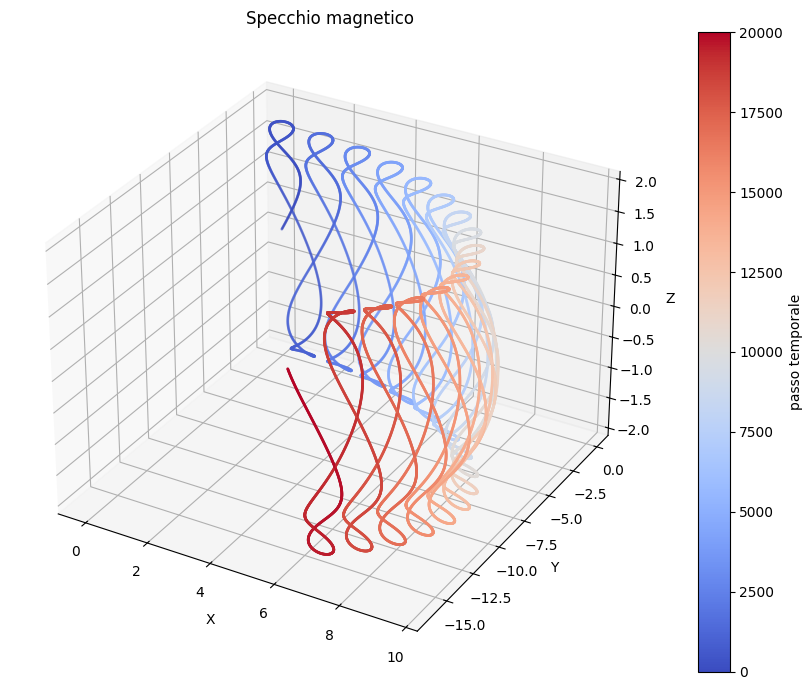

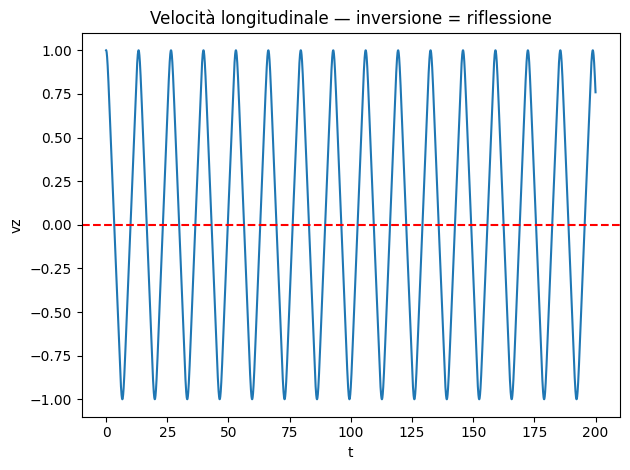

In [62]:
import math
import numpy as np
import matplotlib.pyplot as plt

q = 1.0
m = 1.0
B0 = 1.0
alpha = 0.5

N = 20000
DT = 0.01

def Bz(z):
    return B0 * (1 + alpha * z**2)

def dBdz(z):
    return B0 * 2 * alpha * z

def g(state, t):
    x, vx, y, vy, z, vz = state

    B  = Bz(z)
    dB = dBdz(z)

    vperp2 = vx**2 + vy**2
    mu = 0.5 * m * vperp2 / B

    dvx = (q / m) * vy * B
    dvy = -(q / m) * vx * B
    dvz = -(mu / m) * dB

    return np.array([vx, dvx, vy, dvy, vz, dvz])

def rungeKutta(y, t, dt):
    C1 = g(y, t)
    C2 = g(y + dt * C1 / 2, t + dt / 2)
    C3 = g(y + dt * C2 / 2, t + dt / 2)
    C4 = g(y + dt * C3,     t + dt)
    return y + dt * (C1 + 2*C2 + 2*C3 + C4) / 6

vperp0 = 1.0
vz0    = 1.0

Y = np.array([0.0, vperp0, 0.0, 0.0, 0.0, vz0])

X1 = np.zeros(N + 1);  X1[0] = Y[0]
Y1 = np.zeros(N + 1);  Y1[0] = Y[2]
Z1 = np.zeros(N + 1);  Z1[0] = Y[4]
VZ = np.zeros(N + 1);  VZ[0] = Y[5]

for i in range(N):
    t = DT * i
    Y = rungeKutta(Y, t, DT)
    X1[i+1] = Y[0]
    Y1[i+1] = Y[2]
    Z1[i+1] = Y[4]
    VZ[i+1] = Y[5]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
sc  = ax.scatter(X1, Y1, Z1, c=np.arange(N+1), cmap='coolwarm', s=1)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.colorbar(sc, label='passo temporale')
plt.title('Specchio magnetico')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(np.arange(N+1) * DT, VZ)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('t'); plt.ylabel('vz')
plt.title('Velocità longitudinale — inversione = riflessione')
plt.tight_layout()
plt.show()

In [63]:
plt.scatter

<function matplotlib.pyplot.scatter(x: 'float | ArrayLike', y: 'float | ArrayLike', s: 'float | ArrayLike | None' = None, c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None, marker: 'MarkerType | None' = None, cmap: 'str | Colormap | None' = None, norm: 'str | Normalize | None' = None, vmin: 'float | None' = None, vmax: 'float | None' = None, alpha: 'float | None' = None, linewidths: 'float | Sequence[float] | None' = None, *, edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None, plotnonfinite: 'bool' = False, data=None, **kwargs) -> 'PathCollection'>